# Loading Dataset

In [1496]:
import pandas as pd
import numpy as np

In [1497]:
data=pd.read_csv('./data/job.csv')
data.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


# Preprocessing

In [1498]:
data.drop(['ssc_b','hsc_b','hsc_s','degree_t','salary'], axis=1, inplace=True)

In [1499]:
data.head()

,sl_no,gender,ssc_p,hsc_p,degree_p,workex,etest_p,specialisation,mba_p,status
0,1,M,67.00,91.00,58.00,No,55.0,Mkt&HR,58.80,Placed
1,2,M,79.33,78.33,77.48,Yes,86.5,Mkt&Fin,66.28,Placed
2,3,M,65.00,68.00,64.00,No,75.0,Mkt&Fin,57.80,Placed
3,4,M,56.00,52.00,52.00,No,66.0,Mkt&HR,59.43,Not Placed
4,5,M,85.80,73.60,73.30,No,96.8,Mkt&Fin,55.50,Placed


In [1500]:
data.shape

(215, 10)

In [1501]:
data.isnull().sum()

sl_no             0
gender            0
ssc_p             0
hsc_p             0
degree_p          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
dtype: int64

# Encoding

In [1502]:
data.head()

,sl_no,gender,ssc_p,hsc_p,degree_p,workex,etest_p,specialisation,mba_p,status
0,1,M,67.00,91.00,58.00,No,55.0,Mkt&HR,58.80,Placed
1,2,M,79.33,78.33,77.48,Yes,86.5,Mkt&Fin,66.28,Placed
2,3,M,65.00,68.00,64.00,No,75.0,Mkt&Fin,57.80,Placed
3,4,M,56.00,52.00,52.00,No,66.0,Mkt&HR,59.43,Not Placed
4,5,M,85.80,73.60,73.30,No,96.8,Mkt&Fin,55.50,Placed


In [1503]:
data['gender'].value_counts()

gender
M    139
F     76
Name: count, dtype: int64

In [1504]:
data['workex'].value_counts()

workex
No     141
Yes     74
Name: count, dtype: int64

In [1505]:
data['specialisation'].value_counts()

specialisation
Mkt&Fin    120
Mkt&HR      95
Name: count, dtype: int64

In [1506]:
data['status'].value_counts()

status
Placed        148
Not Placed     67
Name: count, dtype: int64

In [1507]:
data['gender']=data.gender.map({'M':0,'F':1})
data['workex']=data['workex'].map({'No':0,'Yes':1})
data['status']=data['status'].map({'Not Placed':0,'Placed':1})
data['specialisation']=data['specialisation'].map({'Mkt&HR':0,'Mkt&Fin':1})

In [1508]:
data.head()

,sl_no,gender,ssc_p,hsc_p,degree_p,workex,etest_p,specialisation,mba_p,status
0,1,0,67.00,91.00,58.00,0,55.0,0,58.80,1
1,2,0,79.33,78.33,77.48,1,86.5,1,66.28,1
2,3,0,65.00,68.00,64.00,0,75.0,1,57.80,1
3,4,0,56.00,52.00,52.00,0,66.0,0,59.43,0
4,5,0,85.80,73.60,73.30,0,96.8,1,55.50,1


# Balance Dataset

In [1509]:
data['status'].value_counts()

status
1    148
0     67
Name: count, dtype: int64

In [1510]:
from sklearn.utils import resample

major=data[data['status']==1]
minor=data[data['status']==0]

resapmled=resample(minor,
         replace=True,
         n_samples=len(major),
         random_state=42
    
)
balanced_data=pd.concat([major,resapmled])

In [1511]:
balanced_data['status'].value_counts()

status
1    148
0    148
Name: count, dtype: int64

# Train Test Split


In [1512]:
X=balanced_data.copy().drop('status',axis=1)
y=balanced_data['status']

In [1513]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y, test_size=0.3,random_state=2)
X_train.shape, X_test.shape

((207, 9), (89, 9))

# Feature Scaling

In [1514]:
X_train.head()

,sl_no,gender,ssc_p,hsc_p,degree_p,workex,etest_p,specialisation,mba_p
185,186,1,88.00,72.0,78.00,0,82.00,0,71.43
92,93,1,60.23,69.0,66.00,0,72.00,1,59.47
22,23,1,69.80,60.8,72.23,0,55.53,0,68.81
157,158,0,66.50,62.5,60.90,0,93.40,1,55.03
27,28,0,63.00,67.0,66.00,0,68.00,0,57.69


In [1515]:
# scale each features
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.fit_transform(X_test)


# 1-K nearest neighbor

In [1516]:
from sklearn.neighbors import KNeighborsClassifier

knn=KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train,y_train)

knn_Y_pred=knn.predict(X_test)
knn_accuracy=knn.score(X_test,y_test)
knn_accuracy

0.797752808988764

In [1517]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

confusion_matrix(y_test, knn_Y_pred)

array([[34, 12],
       [ 6, 37]])

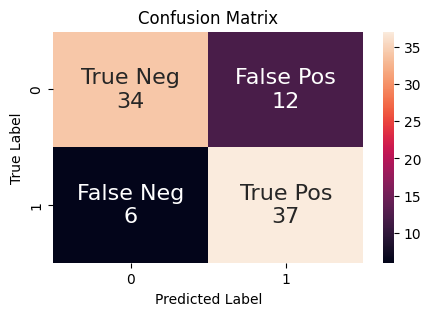

In [1518]:
# creating confusion matrix heatmap
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

conf_mat = confusion_matrix(y_test, knn_Y_pred)
fig = plt.figure(figsize=(5,3))

group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in conf_mat.flatten()]
labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_names,group_counts)]
labels = np.asarray(labels).reshape(2,2)

sns.heatmap(conf_mat, annot=labels, annot_kws={"size": 16}, fmt='')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Decision Tree

In [1519]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier

decision_tree=DecisionTreeClassifier()
decision_tree.fit(X_train,y_train)
decision_tree_y_pred=decision_tree.predict(X_test)
decision_tree_accuracy=decision_tree.score(X_test,y_test)
decision_tree_accuracy


0.8202247191011236

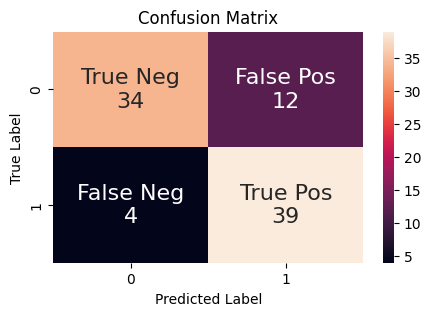

In [1520]:
# creating confusion matrix heatmap

conf_mat = confusion_matrix(y_test, decision_tree_y_pred)
fig = plt.figure(figsize=(5,3))
group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in
                conf_mat.flatten()]
labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_names,group_counts)]
labels = np.asarray(labels).reshape(2,2)
sns.heatmap(conf_mat, annot=labels, annot_kws={"size": 16}, fmt='')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# SVM

In [1521]:
# Support Vector Machine
from sklearn.svm import SVC
svc = SVC()
svc.fit(X_train, y_train)
svm_Y_pred = svc.predict(X_test)
svc_accuracy = svc.score(X_test, y_test)
svc_accuracy

0.8764044943820225

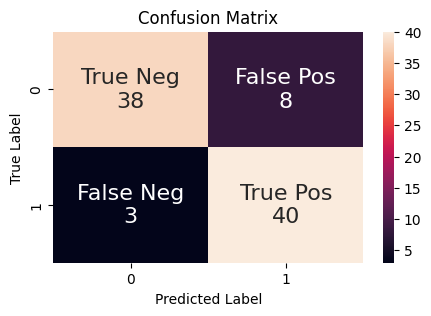

In [1522]:
# creating confusion matrix heatmap

conf_mat = confusion_matrix(y_test, svm_Y_pred)
fig = plt.figure(figsize=(5,3))
group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in
                conf_mat.flatten()]
labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_names,group_counts)]
labels = np.asarray(labels).reshape(2,2)
sns.heatmap(conf_mat, annot=labels, annot_kws={"size": 16}, fmt='')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Random Forest

In [1523]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(n_estimators=1000)
random_forest.fit(X_train, y_train)
random_forest_Y_pred = random_forest.predict(X_test)
random_forest.score(X_train, y_train)
random_forest_accuracy = random_forest.score(X_test, y_test)
random_forest_accuracy

0.9213483146067416

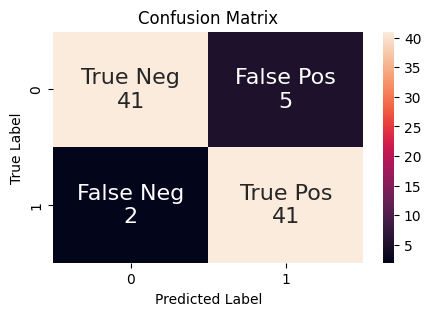

In [1524]:
# creating confusion matrix heatmap

conf_mat = confusion_matrix(y_test, random_forest_Y_pred)
fig = plt.figure(figsize=(5,3))
group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in
                conf_mat.flatten()]
labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_names,group_counts)]
labels = np.asarray(labels).reshape(2,2)
sns.heatmap(conf_mat, annot=labels, annot_kws={"size": 16}, fmt='')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Gaussian Naive Bayes

In [1525]:
from sklearn.naive_bayes import GaussianNB
gaussian = GaussianNB()
gaussian.fit(X_train, y_train)
gaussian_Y_pred = gaussian.predict(X_test)
gaussian_accuracy = gaussian.score(X_test, y_test)
gaussian_accuracy

0.8202247191011236

# Logistic Regression

In [1526]:
from sklearn.linear_model import LogisticRegression
lg = LogisticRegression()
lg.fit(X_train, y_train)
lg_Y_pred = lg.predict(X_test)
lg_accuracy = lg.score(X_test, y_test)
lg_accuracy

0.8314606741573034

# Sıngle ınput predictions

In [1527]:
random_forest.predict(X_train[10].reshape(1,-1))

array([0])

In [1528]:
print("Predicted Class :",random_forest.predict(X_train[10].reshape(1,-1))[0])
print("Actual Class:", y_test.iloc[10])

Predicted Class : 0
Actual Class: 1


In [1529]:
print("Predicted Class :",random_forest.predict(X_train[50].reshape(1,-1))[0])
print("Actual Class:", y_test.iloc[50])

Predicted Class : 0
Actual Class: 1


# Predictive system

In [1532]:
def prediction(sl_no, gender, ssc_p, hsc_p, degree_p, workex, etest_p, specialisation, mba_p):
    data = {
    'sl_no': [sl_no],
    'gender': [gender],
    'ssc_p': [ssc_p],
    'hsc_p': [hsc_p],
    'degree_p': [degree_p],
    'workex': [workex],
    'etest_p': [etest_p],
    'specialisation': [specialisation],
    'mba_p': [mba_p]
    }
    data = pd.DataFrame(data)
    data['gender'] = data['gender'].map({'M':0,"F":1})
    data['workex'] = data['workex'].map({"Yes":1,"No":0})
    data['specialisation'] = data['specialisation'].map({"Mkt&HR":0,"Mkt&Fin":1})
    scaled_df = scaler.fit_transform(data)
    result = random_forest.predict(scaled_df).reshape(1, -1)
    return result[0]

In [1533]:
sl_no =11
gender = "F"
ssc_p =58.
hsc_p = 61.
degree_p = 60.
workex = "Yes"
etest_p = 62.
specialisation = "Mkt&Fin"
mba_p = 60.85

result = prediction(sl_no, gender, ssc_p, hsc_p, degree_p, workex, etest_p, specialisation, mba_p)

if result == 1:
    print('place')

else:
    print('not place')

not place


# Save Files

In [1534]:
import pickle
pickle.dump(random_forest,open('model.pkl','wb'))
pickle.dump(scaler,open('scaler.pkl','wb'))